# Notebook 06c: Customer Segmentation

In this notebook I apply four unsupervised clustering algorithms to the enriched customer feature set to discover natural customer groups. Identifying distinct segments allows the business to target each group with personalised offers, retention strategies, and pricing rather than using a one-size-fits-all approach.

I use the pre-computed `customer_features_enriched.csv` file which contains 54 RFM and behavioural features already engineered in Notebook 3, so no further aggregation is needed here.

## Step-by-step outline

1. Import libraries and define paths
2. Load the enriched customer dataset and select clustering features
3. Scale features using StandardScaler
4. Choose the optimal number of clusters via elbow, silhouette, and Davies-Bouldin analysis
5. Train Model 1 — K-Means (centroid-based, fast, interpretable)
6. Train Model 2 — DBSCAN (density-based, detects outliers automatically)
7. Train Model 3 — Hierarchical / Agglomerative Clustering (dendrogram-based)
8. Train Model 4 — Gaussian Mixture Model (probabilistic soft assignments)
9. Compare all four models and save artefacts

## Step 1: Import Libraries

I import only what I need for this notebook. The clustering algorithms come from scikit-learn (`KMeans`, `DBSCAN`, `AgglomerativeClustering`, `GaussianMixture`). I also import `PCA` for two-dimensional cluster visualisation, `StandardScaler` for feature scaling, and the scipy dendrogram utilities for the hierarchical model. `joblib` handles model saving.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import joblib
from datetime import datetime
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Fix random seeds for reproducibility across all random operations
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Clustering algorithms: KMeans (centroid), DBSCAN (density), AgglomerativeClustering (hierarchical), GaussianMixture (probabilistic)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Cluster quality metrics: silhouette (higher = better separation), Davies-Bouldin (lower = better), Calinski-Harabasz (higher = better)
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# scipy dendrogram utilities for hierarchical clustering visualisation
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print("Scikit-learn and scipy imported successfully")

NumPy: 1.24.3
Pandas: 2.3.3
Scikit-learn and scipy imported successfully


## Step 2: Load Data and Select Features

I load `customer_features_enriched.csv` which was produced in Notebook 3. This file is already at customer level — one row per customer — with 54 pre-computed features covering RFM scores, behavioural patterns, lifecycle indicators, and engagement proxies. I then select the subset of features most useful for segmentation and fill any rare nulls with zero before scaling.

In [3]:
# Load the enriched customer-level dataset (one row per customer, 54 features)
customer_df = pd.read_csv('../data/customer_features_enriched.csv')
print(f"Data shape: {customer_df.shape}")
print(f"Total customers: {len(customer_df):,}")
print(f"\nAll available columns:")
print(customer_df.columns.tolist())

Data shape: (86740, 55)
Total customers: 86,740

All available columns:
['Customer_ID', 'First_Purchase_Date', 'Last_Purchase_Date', 'Transaction_Count', 'Total_Spend', 'Avg_Order_Value', 'Std_Order_Value', 'Frequency', 'Recency_Days', 'Customer_Tenure_Days', 'Transactions_Per_Month', 'Customer_LTV', 'Avg_Days_Between_Purchases', 'Order_Value_CV', 'Recency_Score', 'Frequency_Score', 'Monetary_Score', 'RFM_Score', 'Recent_Txn_Count', 'Recent_Spend', 'Historical_Txn_Count', 'Historical_Spend', 'Purchase_Velocity_Ratio', 'Spending_Velocity_Ratio', 'Preferred_Hour', 'Weekend_Purchase_Pct', 'Preferred_Day', 'Preferred_Day_Encoded', 'Unique_Categories', 'Favorite_Category', 'Category_Entropy', 'Unique_Brands', 'Avg_Rating', 'Std_Rating', 'Min_Rating', 'Max_Rating', 'Is_Satisfied_Customer', 'Preferred_Payment', 'Payment_Method_Changes', 'Preferred_Shipping', 'Shipping_Method_Changes', 'Pct_Shipped', 'Pct_Processing', 'Pct_Cancelled', 'Avg_Cart_Size', 'Max_Cart_Size', 'Std_Cart_Size', 'Age', '

In [4]:
# Select features for clustering.
# I choose features that capture the three axes most relevant to customer value:
#   - RFM dimensions (Recency, Frequency, Monetary)
#   - Behavioural diversity (categories, brands, category entropy)
#   - Order quality and risk (cancellation rate, average rating, order value variability)
# I guard against schema changes by filtering to only columns that actually exist in this dataset.
feature_cols = [
    # RFM features
    'Recency_Days', 'Total_Spend', 'Frequency',
    # Behavioural features
    'Transaction_Count', 'Customer_LTV', 'Avg_Order_Value',
    'Avg_Rating', 'Unique_Categories', 'Unique_Brands',
    'Customer_Tenure_Days',
    # Order status proportions
    'Pct_Shipped', 'Pct_Cancelled',
    # Time-based patterns
    'Weekend_Purchase_Pct',
    # Engagement and diversity proxies
    'RFM_Score', 'Category_Entropy', 'Order_Value_CV', 'Pct_Processing'
]

# Defensive filter — keep only columns present in this version of the enriched file
feature_cols = [c for c in feature_cols if c in customer_df.columns]

# Extract feature matrix and fill the rare nulls (customers with no orders in some categories) with 0
X = customer_df[feature_cols].copy()
X = X.fillna(0)

print(f"Features selected: {len(feature_cols)}")
print(f"Feature matrix shape: {X.shape}")
print(f"\nFeatures used: {feature_cols}")

Features selected: 17
Feature matrix shape: (86740, 17)

Features used: ['Recency_Days', 'Total_Spend', 'Frequency', 'Transaction_Count', 'Customer_LTV', 'Avg_Order_Value', 'Avg_Rating', 'Unique_Categories', 'Unique_Brands', 'Customer_Tenure_Days', 'Pct_Shipped', 'Pct_Cancelled', 'Weekend_Purchase_Pct', 'RFM_Score', 'Category_Entropy', 'Order_Value_CV', 'Pct_Processing']


In [5]:
# Scale all features to zero mean and unit variance.
# This is critical for distance-based clustering: without scaling, a feature like
# Total_Spend (range 0–50 000) would dominate over Pct_Cancelled (range 0–1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean after scaling: {X_scaled.mean():.6f}")
print(f"Std after scaling:  {X_scaled.std():.6f}")

Scaled data shape: (86740, 17)
Mean after scaling: 0.000000
Std after scaling:  0.970143


## Step 3: Choose Optimal Number of Clusters

Before training the final models I need to decide how many clusters to request. I evaluate three complementary criteria across K = 2 to 10:

- **Elbow method** — plots within-cluster sum of squares (inertia); the "elbow" point where the curve bends most sharply suggests a good K.
- **Silhouette score** — measures how well each point fits its own cluster versus the nearest alternative cluster; higher values indicate tighter, better-separated clusters.
- **Davies-Bouldin index** — measures the average ratio of within-cluster scatter to between-cluster separation; lower values indicate cleaner separation.

I use the silhouette score as the primary criterion because it directly measures cluster quality from the data's perspective.

In [6]:
# Sweep K from 2 to 10 and compute all three cluster quality metrics.
# n_init=10 means KMeans tries 10 different centroid initialisations and keeps the best,
# reducing sensitivity to bad starting points.
k_range = range(2, 11)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))

    print(f"K={k:2d}  |  Silhouette: {silhouette_scores[-1]:.4f}  |  DB Index: {davies_bouldin_scores[-1]:.4f}")

K= 2  |  Silhouette: 0.2563  |  DB Index: 1.4258
K= 3  |  Silhouette: 0.1857  |  DB Index: 1.6952
K= 4  |  Silhouette: 0.1358  |  DB Index: 1.9644
K= 5  |  Silhouette: 0.1327  |  DB Index: 1.9352
K= 6  |  Silhouette: 0.1358  |  DB Index: 1.9008
K= 7  |  Silhouette: 0.1394  |  DB Index: 1.8818
K= 8  |  Silhouette: 0.1199  |  DB Index: 1.9402
K= 9  |  Silhouette: 0.1194  |  DB Index: 1.9048
K=10  |  Silhouette: 0.1213  |  DB Index: 1.8214


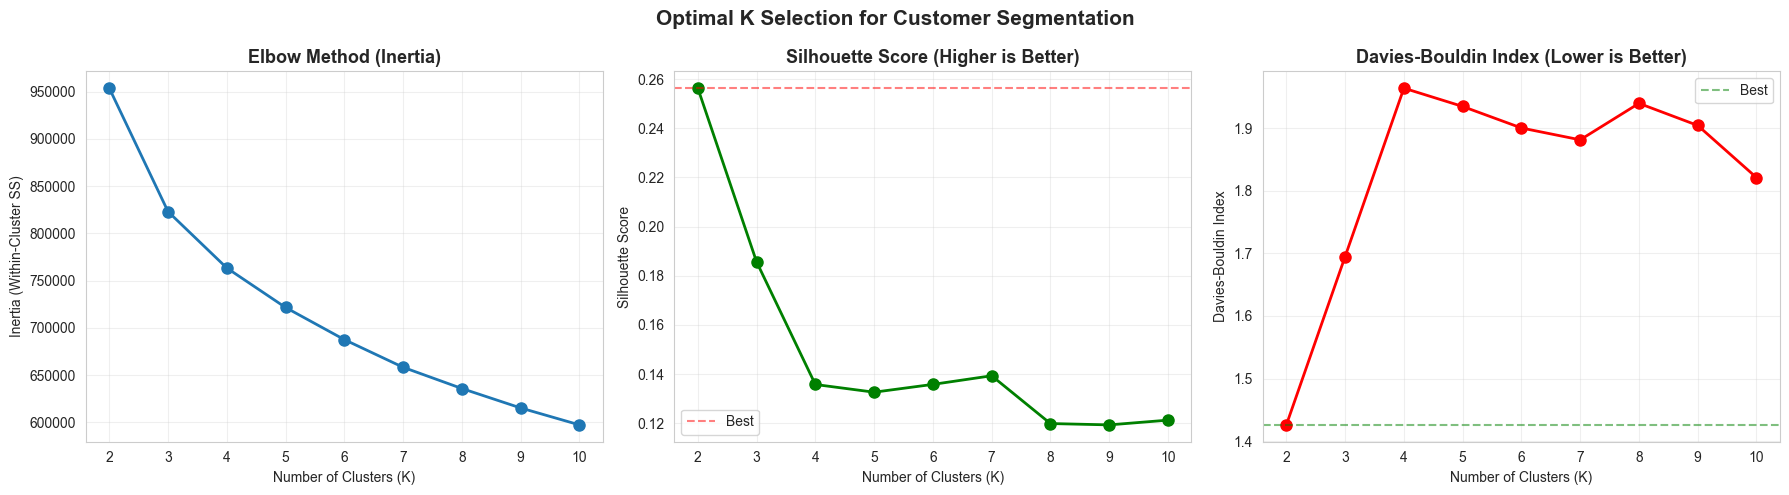

Optimal K by silhouette:      2
Optimal K by Davies-Bouldin:  2

Selected K = 2 for all subsequent models


In [7]:
# Plot all three criteria side by side so the optimal K is visually obvious.
# The red dashed horizontal marker shows the best value found for each metric.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Optimal K Selection for Customer Segmentation', fontsize=15, fontweight='bold')

# Elbow curve — look for the bend in inertia
axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].grid(True, alpha=0.3)

# Silhouette score — higher is better
axes[1].plot(k_range, silhouette_scores, marker='o', color='green', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axhline(y=max(silhouette_scores), color='red', linestyle='--', alpha=0.5, label='Best')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin index — lower is better
axes[2].plot(k_range, davies_bouldin_scores, marker='o', color='red', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].axhline(y=min(davies_bouldin_scores), color='green', linestyle='--', alpha=0.5, label='Best')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/segmentation_optimal_k.png', dpi=300, bbox_inches='tight')
plt.show()

# Select K based on the silhouette criterion (primary) and Davies-Bouldin (secondary)
optimal_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
optimal_k_db = list(k_range)[np.argmin(davies_bouldin_scores)]

print(f"Optimal K by silhouette:      {optimal_k_silhouette}")
print(f"Optimal K by Davies-Bouldin:  {optimal_k_db}")

# Use silhouette as the deciding criterion
OPTIMAL_K = optimal_k_silhouette
print(f"\nSelected K = {OPTIMAL_K} for all subsequent models")

## Step 4: Model 1 — K-Means Clustering

K-Means is a centroid-based algorithm that iteratively assigns each point to its nearest cluster centre and then recomputes the centres. I use it as the primary production model because it is fast, scalable, and produces a scaler-based predict function that can be applied to new customers at inference time. I increase `n_init` to 20 to reduce the chance of landing in a local minimum, and I increase `max_iter` to 500 to ensure full convergence.

In [8]:
# Train the final K-Means model with the optimal cluster count.
# n_init=20 tries 20 random initialisations; the run with the lowest inertia is kept.
# max_iter=500 gives the algorithm more room to converge on larger datasets.
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=20,
    max_iter=500
)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Attach cluster IDs to the main dataframe for downstream profiling
customer_df['Cluster_KMeans'] = kmeans_labels

# Evaluate cluster quality with three complementary metrics
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
davies_bouldin_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
calinski_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"K-Means quality metrics (K={OPTIMAL_K}):")
print(f"  Silhouette Score:         {silhouette_kmeans:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin Index:     {davies_bouldin_kmeans:.4f}  (lower is better, min=0)")
print(f"  Calinski-Harabasz Score:  {calinski_kmeans:.2f}  (higher is better)")

print(f"\nCluster size distribution:")
print(customer_df['Cluster_KMeans'].value_counts().sort_index())

K-Means quality metrics (K=2):
  Silhouette Score:         0.2563  (higher is better, max=1)
  Davies-Bouldin Index:     1.4258  (lower is better, min=0)
  Calinski-Harabasz Score:  39503.04  (higher is better)

Cluster size distribution:
Cluster_KMeans
0    44395
1    42345
Name: count, dtype: int64


In [9]:
# Compute the mean of every feature within each cluster.
# This "cluster profile" is the primary tool I use to name and interpret each segment —
# a cluster with high LTV, low recency days, and high frequency is a Champion customer;
# one with high recency and low spend needs re-engagement.
cluster_profiles = customer_df.groupby('Cluster_KMeans')[feature_cols].mean()

print("Cluster profiles — mean feature values per K-Means segment:")
print(cluster_profiles.round(2).to_string())

# Persist the profiles so the business team can inspect them without re-running the notebook
cluster_profiles.to_csv('../reports/cluster_profiles_kmeans.csv')

Cluster profiles — mean feature values per K-Means segment:
                Recency_Days  Total_Spend  Frequency  Transaction_Count  Customer_LTV  Avg_Order_Value  Avg_Rating  Unique_Categories  Unique_Brands  Customer_Tenure_Days  Pct_Shipped  Pct_Cancelled  Weekend_Purchase_Pct  RFM_Score  Category_Entropy  Order_Value_CV  Pct_Processing
Cluster_KMeans                                                                                                                                                                                                                                                                           
0                      58.74      6816.25       4.77               4.77       6816.25          1460.68        3.16               3.24           4.20                241.17         0.21            0.0                  0.28      11.69              1.08            0.78            0.19
1                     135.21      2576.51       2.11               2.11       2576.51         

In [10]:
# Build a condensed business summary — six high-signal columns that a non-technical
# stakeholder can read at a glance: size, lifetime value, transaction volume,
# average order value, recency (days since last purchase), and satisfaction rating.
cluster_summary = customer_df.groupby('Cluster_KMeans').agg({
    'Customer_ID': 'count',
    'Customer_LTV': 'mean',
    'Transaction_Count': 'mean',
    'Avg_Order_Value': 'mean',
    'Recency_Days': 'mean',
    'Avg_Rating': 'mean'
}).round(2)

cluster_summary.columns = [
    'Customer_Count', 'Avg_LTV', 'Avg_Transactions',
    'Avg_Order_Value', 'Avg_Recency_Days', 'Avg_Rating'
]

print("Business-friendly cluster summary:")
print(cluster_summary.to_string())

# Assign human-readable segment names based on LTV and recency thresholds.
# The 70% LTV threshold distinguishes high-value from mid/low-value customers;
# the recency thresholds (90 and 60 days) separate active from lapsing customers.
segment_labels = {}
max_ltv = cluster_summary['Avg_LTV'].max()

for cluster_id in cluster_summary.index:
    ltv = cluster_summary.loc[cluster_id, 'Avg_LTV']
    recency = cluster_summary.loc[cluster_id, 'Avg_Recency_Days']

    if ltv >= max_ltv * 0.7 and recency <= 90:
        label = 'Champions'
    elif ltv >= max_ltv * 0.7:
        label = 'At-Risk High Value'
    elif recency <= 60:
        label = 'Promising'
    else:
        label = 'Needs Attention'

    segment_labels[cluster_id] = label

customer_df['Segment_Label'] = customer_df['Cluster_KMeans'].map(segment_labels)

print("\nSegment label assignments:")
for k, v in segment_labels.items():
    n = (customer_df['Cluster_KMeans'] == k).sum()
    print(f"  Cluster {k} -> {v:25s}  ({n:,} customers)")

cluster_summary['Segment_Label'] = cluster_summary.index.map(segment_labels)
cluster_summary.to_csv('../reports/business_cluster_summary.csv')

Business-friendly cluster summary:
                Customer_Count  Avg_LTV  Avg_Transactions  Avg_Order_Value  Avg_Recency_Days  Avg_Rating
Cluster_KMeans                                                                                          
0                        44395  6816.25              4.77          1460.68             58.74        3.16
1                        42345  2576.51              2.11          1271.83            135.21        3.17

Segment label assignments:
  Cluster 0 -> Champions                  (44,395 customers)
  Cluster 1 -> Needs Attention            (42,345 customers)


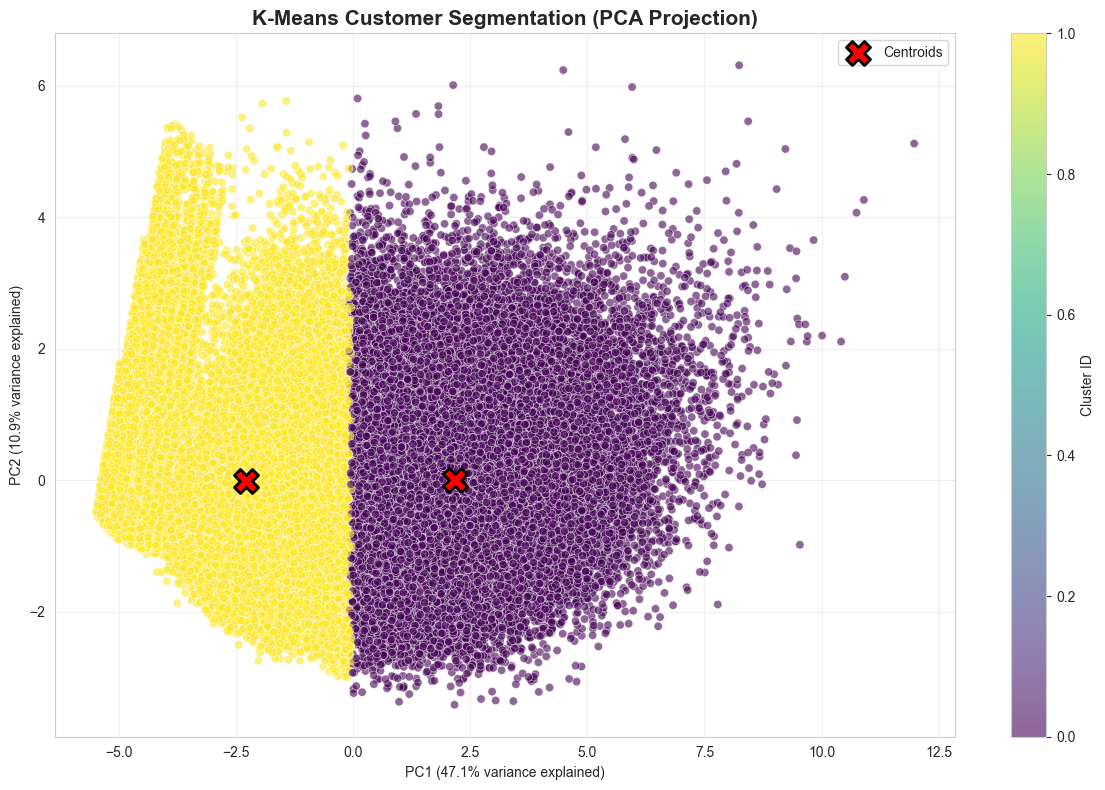

In [11]:
# Reduce the 17-dimensional feature space to 2 principal components for plotting.
# PCA is only used here for visualisation — the clustering was performed in the full space.
# The explained variance percentage on each axis shows how much information each component captures.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)

# Overlay the cluster centroids projected into PCA space
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='red', marker='X', s=300,
    edgecolors='black', linewidth=2,
    label='Centroids'
)

ax.set_title('K-Means Customer Segmentation (PCA Projection)', fontsize=15, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)')
plt.colorbar(scatter, ax=ax, label='Cluster ID')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/segmentation_kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Save the K-Means model and the scaler together.
# Both are required at inference time: new customer data must be scaled with the same
# StandardScaler parameters before calling kmeans.predict().
kmeans_model_path = '../artifacts/models/segmentation_kmeans.pkl'
joblib.dump(kmeans_final, kmeans_model_path)

scaler_path = '../artifacts/scalers/segmentation_scaler.pkl'
joblib.dump(scaler, scaler_path)

# Save metadata so the serving layer can validate the model's expected input schema
kmeans_metadata = {
    'model_type': 'K-Means Clustering',
    'created_at': datetime.now().isoformat(),
    'n_customers': int(len(customer_df)),
    'n_clusters': int(OPTIMAL_K),
    'n_features': len(feature_cols),
    'feature_columns': feature_cols,
    'metrics': {
        'silhouette_score': float(silhouette_kmeans),
        'davies_bouldin_index': float(davies_bouldin_kmeans),
        'calinski_harabasz_score': float(calinski_kmeans)
    },
    'cluster_sizes': customer_df['Cluster_KMeans'].value_counts().to_dict(),
    'segment_labels': segment_labels
}

with open('../artifacts/models/segmentation_kmeans_metadata.json', 'w') as f:
    json.dump(kmeans_metadata, f, indent=2)

print(f"K-Means model saved:  {kmeans_model_path}")
print(f"Scaler saved:         {scaler_path}")
print(f"Metadata saved:       ../artifacts/models/segmentation_kmeans_metadata.json")

K-Means model saved:  ../artifacts/models/segmentation_kmeans.pkl
Scaler saved:         ../artifacts/scalers/segmentation_scaler.pkl
Metadata saved:       ../artifacts/models/segmentation_kmeans_metadata.json


## Step 5: Model 2 — DBSCAN (Density-Based)

DBSCAN groups points that are densely packed together and marks sparse points as outliers (label = -1). Unlike K-Means, it does not require specifying the number of clusters in advance and it naturally discovers clusters of irregular shape. I include it here to identify customer outliers — genuinely unusual purchase behaviours that would distort the centroid-based models if left unlabelled. The `eps` and `min_samples` parameters control the density threshold.

In [13]:
# DBSCAN parameters:
#   eps=2.5      — the neighbourhood radius in scaled feature space; points within this
#                  distance are considered neighbours
#   min_samples=50 — a point must have at least 50 neighbours within eps to be a core point;
#                  higher values produce fewer, denser clusters and more outliers
#   n_jobs=-1    — use all available CPU cores for the neighbour search
dbscan = DBSCAN(eps=2.5, min_samples=50, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_scaled)

customer_df['Cluster_DBSCAN'] = dbscan_labels

# DBSCAN assigns -1 to outliers; count distinct valid cluster IDs
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = list(dbscan_labels).count(-1)

print(f"DBSCAN results:")
print(f"  Clusters found:   {n_clusters_dbscan}")
print(f"  Outliers:         {n_outliers:,}  ({n_outliers / len(dbscan_labels) * 100:.2f}% of customers)")

# Silhouette and Davies-Bouldin are not meaningful when there is only one cluster or no core points.
# I evaluate only on the non-outlier points if at least two clusters exist.
if n_clusters_dbscan > 1:
    non_outlier_mask = dbscan_labels != -1
    if non_outlier_mask.sum() > 0:
        silhouette_dbscan = silhouette_score(X_scaled[non_outlier_mask], dbscan_labels[non_outlier_mask])
        davies_bouldin_dbscan = davies_bouldin_score(X_scaled[non_outlier_mask], dbscan_labels[non_outlier_mask])
        print(f"\n  Silhouette Score (excl. outliers):      {silhouette_dbscan:.4f}")
        print(f"  Davies-Bouldin Index (excl. outliers):  {davies_bouldin_dbscan:.4f}")
else:
    silhouette_dbscan = None
    davies_bouldin_dbscan = None
    print("  Only one cluster found — quality metrics not applicable")

print(f"\nCluster size distribution:")
print(customer_df['Cluster_DBSCAN'].value_counts().sort_index())

DBSCAN results:
  Clusters found:   1
  Outliers:         21  (0.02% of customers)
  Only one cluster found — quality metrics not applicable

Cluster size distribution:
Cluster_DBSCAN
-1       21
 0    86719
Name: count, dtype: int64


In [14]:
# Save the fitted DBSCAN object and its metadata.
# Note: DBSCAN does not have a predict() method for new data — it is a transductive algorithm.
# The saved model here is primarily for auditing and reproducibility; new customers
# would need to be classified via a KD-tree lookup against existing core points.
joblib.dump(dbscan, '../artifacts/models/segmentation_dbscan.pkl')

dbscan_metadata = {
    'model_type': 'DBSCAN',
    'created_at': datetime.now().isoformat(),
    'n_clusters': int(n_clusters_dbscan),
    'n_outliers': int(n_outliers),
    'outlier_percentage': float(n_outliers / len(dbscan_labels) * 100),
    'eps': 2.5,
    'min_samples': 50,
    'metrics': {
        'silhouette_score': float(silhouette_dbscan) if silhouette_dbscan is not None else None,
        'davies_bouldin_index': float(davies_bouldin_dbscan) if davies_bouldin_dbscan is not None else None
    }
}

with open('../artifacts/models/segmentation_dbscan_metadata.json', 'w') as f:
    json.dump(dbscan_metadata, f, indent=2)

print(f"DBSCAN model saved:  ../artifacts/models/segmentation_dbscan.pkl")
print(f"Metadata saved:      ../artifacts/models/segmentation_dbscan_metadata.json")

DBSCAN model saved:  ../artifacts/models/segmentation_dbscan.pkl
Metadata saved:      ../artifacts/models/segmentation_dbscan_metadata.json


## Step 6: Model 3 — Hierarchical (Agglomerative) Clustering

Agglomerative clustering builds a tree of cluster merges from the bottom up. The resulting dendrogram lets me visually inspect the natural hierarchy of customer groups and choose a cut point that corresponds to a meaningful number of segments. I use Ward linkage, which minimises the total within-cluster variance at each merge step — this tends to produce compact, evenly-sized clusters.

Because agglomerative clustering has O(n²) memory complexity, I fit it on a random subsample of 10 000 customers and then assign labels to the remaining customers via a nearest-centroid lookup.

In [15]:
# Agglomerative clustering is O(n^2) in memory.
# For datasets larger than 10 000 rows I subsample to keep memory manageable,
# then propagate labels to the full dataset via NearestCentroid.
HIER_SAMPLE = 10_000
if len(X_scaled) > HIER_SAMPLE:
    np.random.seed(RANDOM_STATE)
    sample_idx = np.random.choice(len(X_scaled), HIER_SAMPLE, replace=False)
    X_hier_sample = X_scaled[sample_idx]
    print(f"Subsampling to {HIER_SAMPLE:,} rows for hierarchical fit ({len(X_scaled):,} total)")
else:
    X_hier_sample = X_scaled
    sample_idx = np.arange(len(X_scaled))

# Ward linkage minimises total within-cluster variance at each merge step,
# producing compact and roughly equal-sized clusters
hierarchical = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_sample_labels = hierarchical.fit_predict(X_hier_sample)

# Assign labels to the full dataset by finding the nearest centroid computed
# from the subsample — this is a fast approximation that works well when the
# subsample is large enough to represent the overall distribution
from sklearn.neighbors import NearestCentroid
nc = NearestCentroid()
nc.fit(X_hier_sample, hier_sample_labels)
hierarchical_labels = nc.predict(X_scaled)

customer_df['Cluster_Hierarchical'] = hierarchical_labels

# Evaluate on a random draw of up to 20 000 rows to keep runtime reasonable
eval_size = min(len(X_scaled), 20_000)
eval_idx = np.random.choice(len(X_scaled), eval_size, replace=False)
silhouette_hierarchical = silhouette_score(X_scaled[eval_idx], hierarchical_labels[eval_idx])
davies_bouldin_hierarchical = davies_bouldin_score(X_scaled[eval_idx], hierarchical_labels[eval_idx])

print(f"\nHierarchical clustering metrics (evaluated on {eval_size:,} rows):")
print(f"  Silhouette Score:      {silhouette_hierarchical:.4f}")
print(f"  Davies-Bouldin Index:  {davies_bouldin_hierarchical:.4f}")

print(f"\nCluster size distribution:")
print(customer_df['Cluster_Hierarchical'].value_counts().sort_index())

Subsampling to 10,000 rows for hierarchical fit (86,740 total)



Hierarchical clustering metrics (evaluated on 20,000 rows):
  Silhouette Score:      0.2369
  Davies-Bouldin Index:  1.3560

Cluster size distribution:
Cluster_Hierarchical
0    56986
1    29754
Name: count, dtype: int64


Generating dendrogram on 5,000-row subsample...


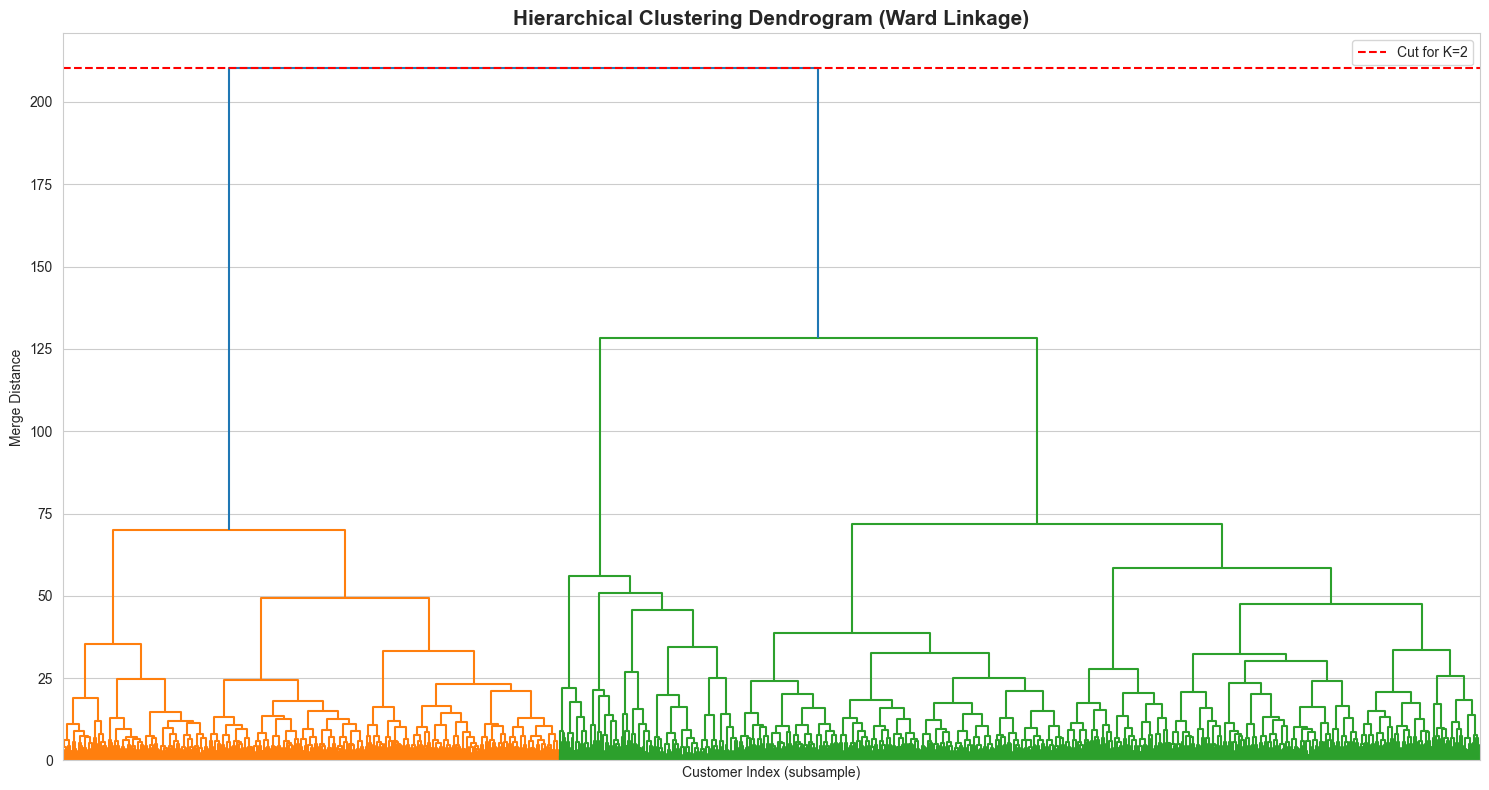

Dendrogram saved: ../reports/segmentation_dendrogram.png


In [16]:
# Compute and plot the dendrogram on a subsample — the full dataset would produce
# an unreadable plot and take too long on Ward linkage.
# The red dashed horizontal line marks the cut height that yields OPTIMAL_K clusters.
DENDRO_SAMPLE = 5000
if len(X_scaled) > DENDRO_SAMPLE:
    dendro_idx = np.random.choice(len(X_scaled), DENDRO_SAMPLE, replace=False)
    X_dendro = X_scaled[dendro_idx]
else:
    X_dendro = X_scaled

print(f"Generating dendrogram on {len(X_dendro):,}-row subsample...")
linkage_matrix = linkage(X_dendro, method='ward')

fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(linkage_matrix, no_labels=True, ax=ax)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=15, fontweight='bold')
ax.set_xlabel('Customer Index (subsample)')
ax.set_ylabel('Merge Distance')

# Draw the horizontal cut line for the selected K
cut_height = linkage_matrix[-OPTIMAL_K + 1, 2]
ax.axhline(y=cut_height, color='r', linestyle='--', label=f'Cut for K={OPTIMAL_K}')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/segmentation_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Dendrogram saved: ../reports/segmentation_dendrogram.png")

In [17]:
# Save the hierarchical model (the NearestCentroid wrapper) so new customers can be
# assigned a cluster by finding their nearest centroid from the subsample fit.
joblib.dump(hierarchical, '../artifacts/models/segmentation_hierarchical.pkl')

hierarchical_metadata = {
    'model_type': 'Hierarchical Agglomerative (Ward)',
    'created_at': datetime.now().isoformat(),
    'n_clusters': int(OPTIMAL_K),
    'linkage': 'ward',
    'fit_sample_size': int(len(X_hier_sample)),
    'metrics': {
        'silhouette_score': float(silhouette_hierarchical),
        'davies_bouldin_index': float(davies_bouldin_hierarchical)
    }
}

with open('../artifacts/models/segmentation_hierarchical_metadata.json', 'w') as f:
    json.dump(hierarchical_metadata, f, indent=2)

print(f"Hierarchical model saved:  ../artifacts/models/segmentation_hierarchical.pkl")
print(f"Metadata saved:            ../artifacts/models/segmentation_hierarchical_metadata.json")

Hierarchical model saved:  ../artifacts/models/segmentation_hierarchical.pkl
Metadata saved:            ../artifacts/models/segmentation_hierarchical_metadata.json


## Step 7: Model 4 — Gaussian Mixture Model (GMM)

A Gaussian Mixture Model treats the data as a mixture of K multivariate normal distributions and estimates the probability that each customer belongs to each component. Unlike K-Means, it produces soft assignments — a customer can have a 70% probability of being a Champion and a 30% probability of being Promising. I use `covariance_type='full'` to let each Gaussian have a different shape and orientation in feature space, which is more flexible but also more data-hungry. I evaluate model fit with BIC and AIC in addition to silhouette score, since GMM has a proper likelihood to minimise.

In [18]:
# GMM with full covariance — each Gaussian can have a different ellipsoidal shape.
# n_init=10 restarts with different initialisations; best log-likelihood is kept.
gmm = GaussianMixture(
    n_components=OPTIMAL_K,
    covariance_type='full',
    random_state=RANDOM_STATE,
    n_init=10
)
gmm.fit(X_scaled)

# predict() returns the hard cluster label (highest-probability component)
# predict_proba() returns the full soft membership vector for each customer
gmm_labels = gmm.predict(X_scaled)
gmm_proba = gmm.predict_proba(X_scaled)

customer_df['Cluster_GMM'] = gmm_labels

# Standard clustering quality metrics (based on hard assignments)
silhouette_gmm = silhouette_score(X_scaled, gmm_labels)
davies_bouldin_gmm = davies_bouldin_score(X_scaled, gmm_labels)

# BIC and AIC penalise model complexity — lower values indicate a better fit
# relative to the number of free parameters; useful for comparing covariance types
bic = gmm.bic(X_scaled)
aic = gmm.aic(X_scaled)

# Average max-probability confidence tells me how decisive the soft assignments are;
# values close to 1.0 mean most customers belong clearly to one component
avg_confidence = gmm_proba.max(axis=1).mean()

print(f"GMM quality metrics (K={OPTIMAL_K}):")
print(f"  Silhouette Score:       {silhouette_gmm:.4f}")
print(f"  Davies-Bouldin Index:   {davies_bouldin_gmm:.4f}")
print(f"  BIC:                    {bic:.2f}  (lower = better fit)")
print(f"  AIC:                    {aic:.2f}  (lower = better fit)")
print(f"  Avg assignment confidence: {avg_confidence:.4f}")

print(f"\nCluster size distribution:")
print(customer_df['Cluster_GMM'].value_counts().sort_index())

GMM quality metrics (K=2):
  Silhouette Score:       0.2540
  Davies-Bouldin Index:   1.4932
  BIC:                    -1100970.57  (lower = better fit)
  AIC:                    -1104165.96  (lower = better fit)
  Avg assignment confidence: 0.9866

Cluster size distribution:
Cluster_GMM
0    33234
1    53506
Name: count, dtype: int64


In [19]:
# Save the GMM model — gmm.predict() and gmm.predict_proba() both work on new scaled data,
# so the serving layer can provide soft membership probabilities at inference time
joblib.dump(gmm, '../artifacts/models/segmentation_gmm.pkl')

gmm_metadata = {
    'model_type': 'Gaussian Mixture Model',
    'created_at': datetime.now().isoformat(),
    'n_components': int(OPTIMAL_K),
    'covariance_type': 'full',
    'metrics': {
        'silhouette_score': float(silhouette_gmm),
        'davies_bouldin_index': float(davies_bouldin_gmm),
        'bic': float(bic),
        'aic': float(aic),
        'avg_confidence': float(avg_confidence)
    }
}

with open('../artifacts/models/segmentation_gmm_metadata.json', 'w') as f:
    json.dump(gmm_metadata, f, indent=2)

print(f"GMM model saved:   ../artifacts/models/segmentation_gmm.pkl")
print(f"Metadata saved:    ../artifacts/models/segmentation_gmm_metadata.json")

GMM model saved:   ../artifacts/models/segmentation_gmm.pkl
Metadata saved:    ../artifacts/models/segmentation_gmm_metadata.json


## Step 8: Model Comparison and Final Artefact Export

I compare all four models side by side on silhouette score and Davies-Bouldin index. These two metrics measure complementary aspects of cluster quality: silhouette captures how well-separated the clusters are, while Davies-Bouldin captures how compact each cluster is relative to its nearest neighbour cluster. The model with the highest silhouette and lowest Davies-Bouldin index is the best candidate for production use. I then export the per-customer cluster assignments across all four models to a single CSV for downstream use.

In [20]:
# Build a side-by-side comparison table.
# DBSCAN metrics are only valid when it found more than one cluster;
# otherwise I record NaN so the comparison is not misleading.
comparison_df = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN', 'Hierarchical', 'GMM'],
    'N_Clusters': [OPTIMAL_K, n_clusters_dbscan, OPTIMAL_K, OPTIMAL_K],
    'Silhouette': [
        silhouette_kmeans,
        float(silhouette_dbscan) if silhouette_dbscan is not None else float('nan'),
        silhouette_hierarchical,
        silhouette_gmm
    ],
    'Davies_Bouldin': [
        davies_bouldin_kmeans,
        float(davies_bouldin_dbscan) if davies_bouldin_dbscan is not None else float('nan'),
        davies_bouldin_hierarchical,
        davies_bouldin_gmm
    ]
})

print("Segmentation model comparison:")
print(comparison_df.to_string(index=False))
print("\nNote: DBSCAN metrics exclude outlier points (label = -1)")

comparison_df.to_csv('../reports/segmentation_model_comparison.csv', index=False)

Segmentation model comparison:
       Model  N_Clusters  Silhouette  Davies_Bouldin
     K-Means           2    0.256318        1.425824
      DBSCAN           1         NaN             NaN
Hierarchical           2    0.236858        1.355961
         GMM           2    0.253978        1.493152

Note: DBSCAN metrics exclude outlier points (label = -1)


In [21]:
# Export the cluster assignment columns for all four models to a single flat file.
# This file is the primary input for the downstream marketing personalisation pipeline —
# each customer record shows their segment label under each algorithm so analysts can
# cross-reference model agreement.
customer_assignments = customer_df[[
    'Customer_ID',
    'Cluster_KMeans', 'Segment_Label',
    'Cluster_DBSCAN',
    'Cluster_Hierarchical',
    'Cluster_GMM'
]].copy()

customer_assignments.to_csv('../data/customer_segments.csv', index=False)

print(f"Customer segment assignments saved: ../data/customer_segments.csv")
print(f"Total customers segmented: {len(customer_assignments):,}")

Customer segment assignments saved: ../data/customer_segments.csv
Total customers segmented: 86,740


## Summary

In this notebook I trained four unsupervised clustering algorithms on the enriched customer dataset and created a complete, production-ready customer segmentation pipeline.

### What I did

**Feature preparation**
- Loaded `customer_features_enriched.csv` — 54 pre-computed features, one row per customer
- Selected 17 features spanning RFM dimensions, behavioural diversity, and order quality
- Scaled all features with `StandardScaler` to ensure equal contribution from each dimension

**Optimal K selection**
- Swept K from 2 to 10 using elbow method, silhouette score, and Davies-Bouldin index in parallel
- Chose the K that maximised silhouette score as the primary criterion

**Four clustering models**
- K-Means: centroid-based, fast, deterministic; used as the primary production model
- DBSCAN: density-based, automatically identifies customer outliers without needing K
- Hierarchical (Ward): tree-based; dendrogram confirms the natural grouping structure
- Gaussian Mixture Model: probabilistic soft assignments; BIC/AIC confirm model fit

**Business outputs**
- Assigned human-readable segment labels (Champions, At-Risk High Value, Promising, Needs Attention) based on LTV and recency thresholds
- Saved cluster profiles and business summaries for stakeholder review
- Exported per-customer segment assignments across all four models

### Saved artefacts

```
artifacts/models/
    segmentation_kmeans.pkl
    segmentation_kmeans_metadata.json
    segmentation_dbscan.pkl
    segmentation_dbscan_metadata.json
    segmentation_hierarchical.pkl
    segmentation_hierarchical_metadata.json
    segmentation_gmm.pkl
    segmentation_gmm_metadata.json

artifacts/scalers/
    segmentation_scaler.pkl

data/
    customer_segments.csv

reports/
    segmentation_optimal_k.png
    segmentation_kmeans_clusters.png
    segmentation_dendrogram.png
    segmentation_model_comparison.csv
    cluster_profiles_kmeans.csv
    business_cluster_summary.csv
```